In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df_raw = pd.read_csv(r'results\uploads\diabetes.csv')
df_clean = None
df_features = None
DATASET_COLUMNS = list(df_raw.columns)
NUMERIC_COLUMNS = df_raw.select_dtypes(include=[np.number]).columns.tolist()
CATEGORICAL_COLUMNS = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()
DATASET_SHAPE = df_raw.shape
ORIGINAL_NUMERIC_COLUMNS = NUMERIC_COLUMNS.copy()
ORIGINAL_CATEGORICAL_COLUMNS = CATEGORICAL_COLUMNS.copy()
print(f"Loaded {DATASET_SHAPE[0]} rows x {DATASET_SHAPE[1]} columns")


Loaded 1150 rows x 20 columns


In [2]:

import json as _json

# Compute correlations for numeric columns
_corr_matrix = df_raw[NUMERIC_COLUMNS].corr() if len(NUMERIC_COLUMNS) > 1 else None
_top_correlations = []
if _corr_matrix is not None:
    for i, col1 in enumerate(NUMERIC_COLUMNS):
        for col2 in NUMERIC_COLUMNS[i+1:]:
            corr_val = abs(_corr_matrix.loc[col1, col2])
            if corr_val > 0.5:
                _top_correlations.append((col1, col2, round(corr_val, 3)))
    _top_correlations.sort(key=lambda x: x[2], reverse=True)
    _top_correlations = _top_correlations[:10]  # Top 10

# Compute skewness for numeric columns
_skewness = {}
for col in NUMERIC_COLUMNS:
    try:
        _skewness[col] = round(float(df_raw[col].skew()), 3)
    except:
        pass
_highly_skewed = [col for col, skew in _skewness.items() if abs(skew) > 1]

# Identify binary columns
_binary_columns = [col for col in df_raw.columns if df_raw[col].nunique() == 2]

# Identify potential target columns (binary or low cardinality categorical)
_potential_targets = [col for col in df_raw.columns if 2 <= df_raw[col].nunique() <= 10]

# Check class balance for potential targets (for class_imbalance skip decision)
_class_balance = {}
for col in _binary_columns + [c for c in _potential_targets if c not in _binary_columns]:
    try:
        counts = df_raw[col].value_counts(normalize=True)
        if len(counts) >= 2:
            majority_pct = float(counts.iloc[0] * 100)
            minority_pct = float(counts.iloc[1] * 100)
            _class_balance[col] = {
                'majority_pct': round(majority_pct, 1),
                'minority_pct': round(minority_pct, 1),
                'is_imbalanced': bool(majority_pct > 70)
            }
    except:
        pass

_profile = {
    'shape': list(df_raw.shape),
    'columns': list(df_raw.columns),
    'dtypes': df_raw.dtypes.astype(str).to_dict(),
    'numeric_columns': NUMERIC_COLUMNS,
    'categorical_columns': CATEGORICAL_COLUMNS,
    'missing_values': df_raw.isnull().sum().to_dict(),
    'missing_pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(1).to_dict(),
    'duplicates': int(df_raw.duplicated().sum()),
    'describe': df_raw.describe().round(2).to_dict(),
    'top_correlations': _top_correlations,
    'highly_skewed_columns': _highly_skewed,
    'skewness': _skewness,
    'binary_columns': _binary_columns,
    'potential_targets': _potential_targets,
    'class_balance': _class_balance,
}
print(_json.dumps(_profile))


{"shape": [1150, 20], "columns": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M", "N", "O", "P", "Q", "R", "S", "T"], "dtypes": {"A": "int64", "B": "int64", "C": "int64", "D": "int64", "E": "int64", "F": "int64", "G": "int64", "H": "int64", "I": "float64", "J": "float64", "K": "float64", "L": "float64", "M": "float64", "N": "float64", "O": "float64", "P": "float64", "Q": "float64", "R": "float64", "S": "int64", "T": "int64"}, "numeric_columns": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M", "N", "O", "P", "Q", "R", "S", "T"], "categorical_columns": [], "missing_values": {"A": 0, "B": 0, "C": 0, "D": 0, "E": 0, "F": 0, "G": 0, "H": 0, "I": 0, "J": 0, "K": 0, "L": 0, "M": 0, "N": 0, "O": 0, "P": 0, "Q": 0, "R": 0, "S": 0, "T": 0}, "missing_pct": {"A": 0.0, "B": 0.0, "C": 0.0, "D": 0.0, "E": 0.0, "F": 0.0, "G": 0.0, "H": 0.0, "I": 0.0, "J": 0.0, "K": 0.0, "L": 0.0, "M": 0.0, "N": 0.0, "O": 0.0, "P": 0.0, "Q": 0.0, "R": 0.0, "S": 0.0, "T": 0.0}, "duplica

In [4]:
# Check value counts and proportions for columns 'A' and 'B'
print("Value counts for column 'A':")
print(df_raw['A'].value_counts(normalize=True))
print("\nValue counts for column 'B':")
print(df_raw['B'].value_counts(normalize=True))

# Generate descriptive statistics for highly skewed columns
skewed_cols = ['A', 'B', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P']
print("\nDescriptive statistics for highly skewed columns:")
print(df_raw[skewed_cols].describe())

# Generate descriptive statistics for the highly correlated columns
correlated_cols = ['C', 'D', 'E', 'F', 'G']
print("\nDescriptive statistics for highly correlated columns:")
print(df_raw[correlated_cols].describe())

Value counts for column 'A':
A
1   0.9965
0   0.0035
Name: proportion, dtype: float64

Value counts for column 'B':
B
1   0.9183
0   0.0817
Name: proportion, dtype: float64

Descriptive statistics for highly skewed columns:
              A         B         I         J         K         L         M         N         O         P
count 1150.0000 1150.0000 1150.0000 1150.0000 1150.0000 1150.0000 1150.0000 1150.0000 1150.0000 1150.0000
mean     0.9965    0.9183   64.0920   23.1020    8.7107    1.8380    0.5612    0.2125    0.0857    0.0373
std      0.0589    0.2741   58.5105   21.6069   11.5708    3.9246    2.4851    1.0576    0.3989    0.1790
min      0.0000    0.0000    0.3493    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000
25%      1.0000    1.0000   22.2690    7.9441    1.2424    0.0819    0.0000    0.0000    0.0000    0.0000
50%      1.0000    1.0000   44.2333   17.0416    4.4336    0.4849    0.0223    0.0016    0.0000    0.0000
75%      1.0000    1.0000   87.839

Chart 1: Correlation Heatmap for columns C, D, E, F, G
This heatmap visualizes the pairwise correlation between columns C, D, E, F, and G. It helps identify which of these numerical features move together (positive correlation) or in opposite directions (negative correlation).

Chart 2: Histograms for columns I, J, K
These histograms display the distributions of columns I, J, and K, showing their central tendency, spread, and skewness, which were identified as highly skewed in prior analysis.

Chart 3: Bar Charts for Imbalanced Binary Columns A and B
These bar charts (count plots) illustrate the distribution of binary values for columns A and B, clearly showing their high imbalance as identified in the prior analysis.

Chart 4: Count Plots for Binary Columns S and T
These count plots show the frequency of each category within the binary columns S and T, providing insight into their balance or imbalance.


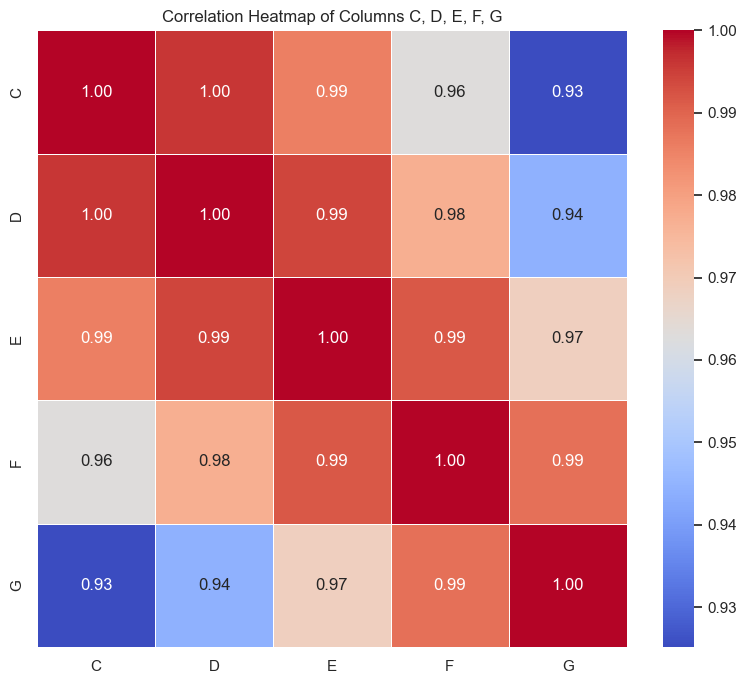

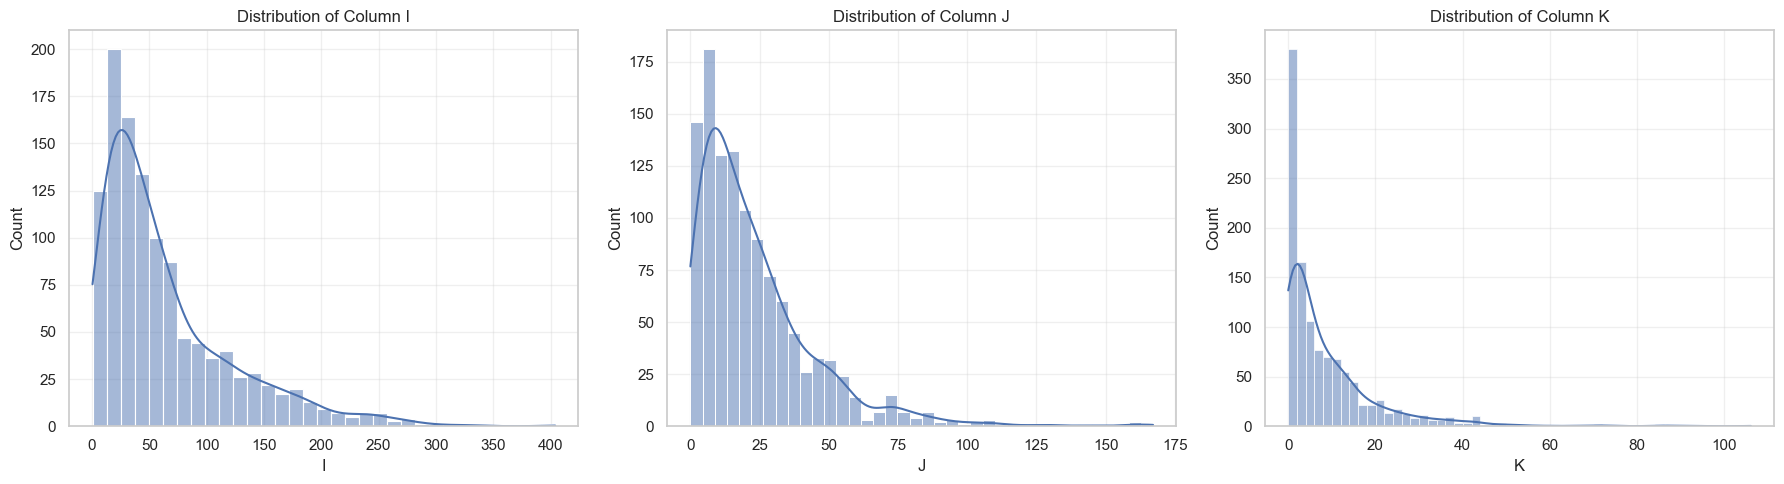

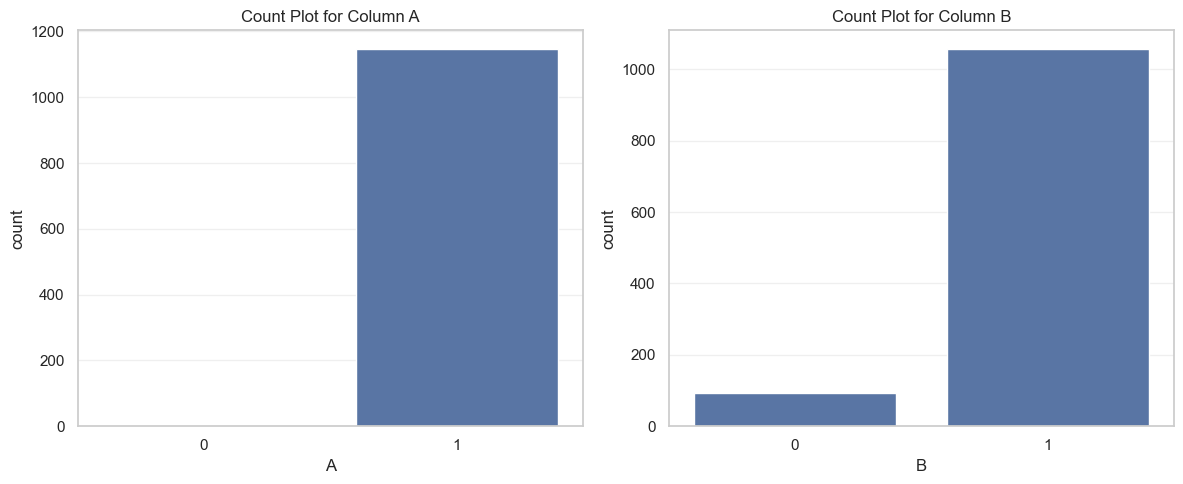

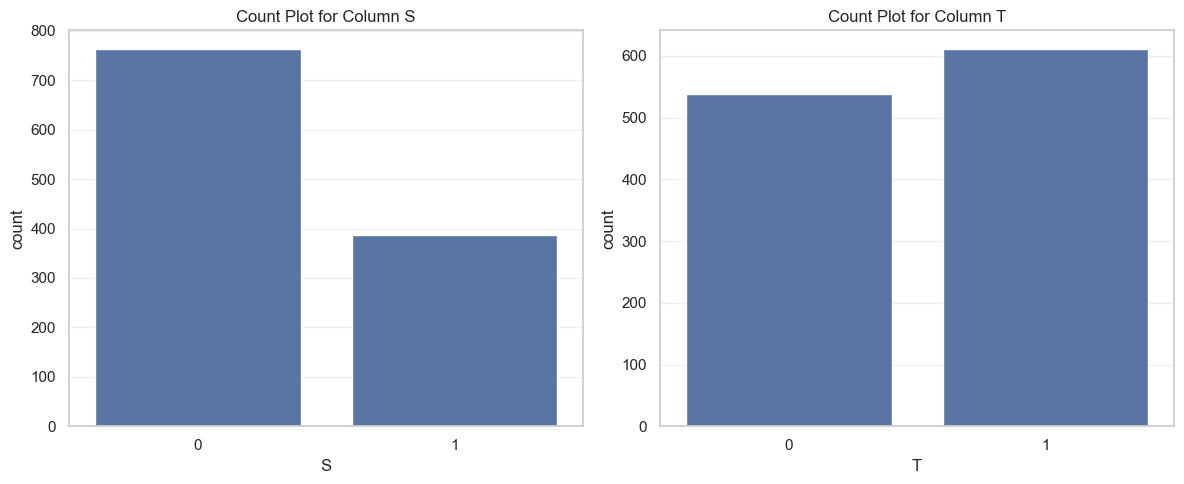

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent style for the plots
sns.set_style('whitegrid')

# Chart 1: Correlation Heatmap for C, D, E, F, G
print('Chart 1: Correlation Heatmap for columns C, D, E, F, G')
plt.figure(figsize=(8, 7))
sns.heatmap(df_raw[['C', 'D', 'E', 'F', 'G']].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Columns C, D, E, F, G')
plt.tight_layout()
plt.show()
print("This heatmap visualizes the pairwise correlation between columns C, D, E, F, and G. It helps identify which of these numerical features move together (positive correlation) or in opposite directions (negative correlation).")

# Chart 2: Histograms for columns I, J, K
print('\nChart 2: Histograms for columns I, J, K')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_raw['I'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Column I')

sns.histplot(df_raw['J'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Column J')

sns.histplot(df_raw['K'], kde=True, ax=axes[2])
axes[2].set_title('Distribution of Column K')

plt.tight_layout()
plt.show()
print("These histograms display the distributions of columns I, J, and K, showing their central tendency, spread, and skewness, which were identified as highly skewed in prior analysis.")

# Chart 3: Bar charts for binary and imbalanced columns A and B
print('\nChart 3: Bar Charts for Imbalanced Binary Columns A and B')
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='A', data=df_raw, ax=axes[0])
axes[0].set_title('Count Plot for Column A')

sns.countplot(x='B', data=df_raw, ax=axes[1])
axes[1].set_title('Count Plot for Column B')

plt.tight_layout()
plt.show()
print("These bar charts (count plots) illustrate the distribution of binary values for columns A and B, clearly showing their high imbalance as identified in the prior analysis.")

# Chart 4: Count plots for binary columns S and T
print('\nChart 4: Count Plots for Binary Columns S and T')
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='S', data=df_raw, ax=axes[0])
axes[0].set_title('Count Plot for Column S')

sns.countplot(x='T', data=df_raw, ax=axes[1])
axes[1].set_title('Count Plot for Column T')

plt.tight_layout()
plt.show()
print("These count plots show the frequency of each category within the binary columns S and T, providing insight into their balance or imbalance.")